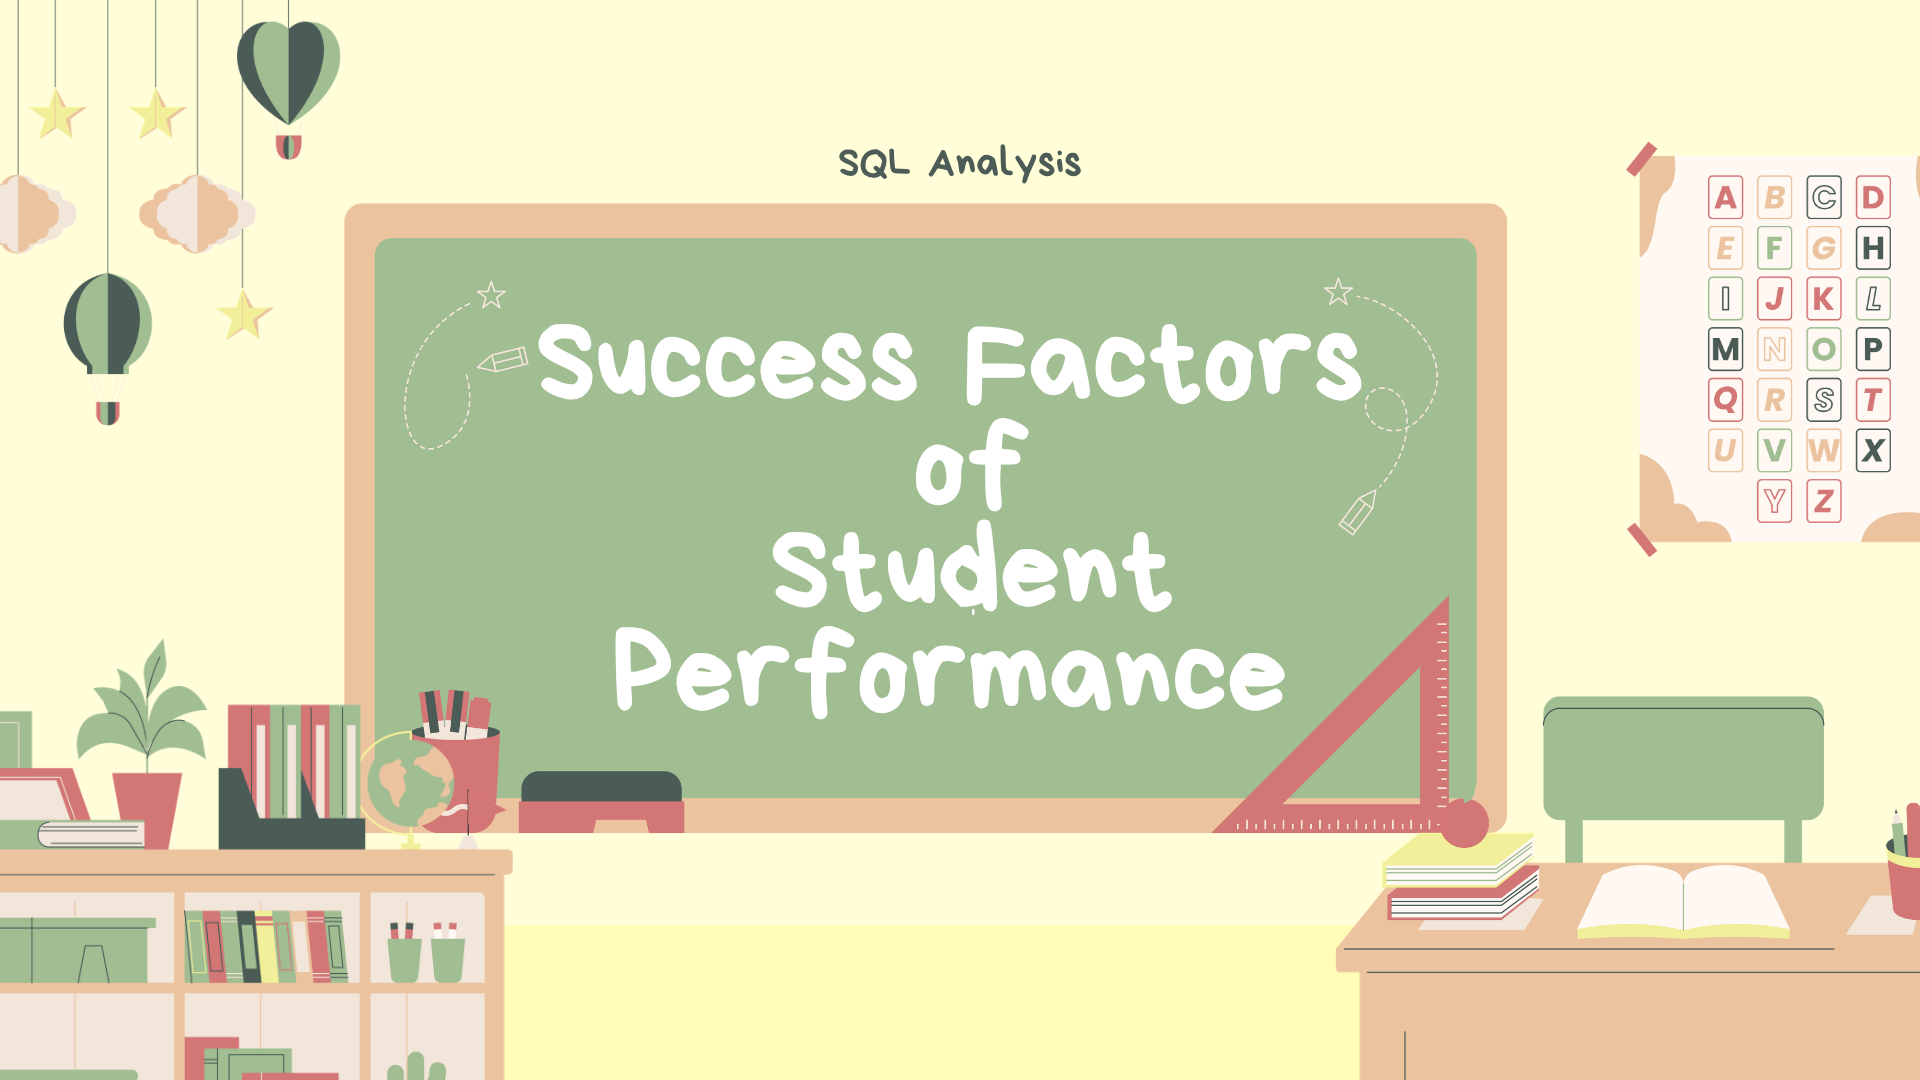

# Success Factors of Student Performance

## Intro
This analysis was inspired by a project on DataCamp about analyzing numerous factors in a student's day-to-day life that could impact their performance on assessments. As a teacher, I love being able to leverage data to help students improve, and I wanted to dive deeper into this dataset to look for patterns of success. I've mixed in examples of my SQL queries and outputs to demonstrate how I interacted with this dataset!

## The Data
The dataset comes from a public project on DataCamp called "Factors That Fuel Student Performance" created by Shahzad Mian and found [here](https://app.datacamp.com/learn/projects/2623). Nulls were identified in 3 columns- 'Teacher_Quality', 'Parental_Education_Level', and 'Distance_From_Home', but no cleaning of the dataset was necessary.
<br>Here is the **schema**:

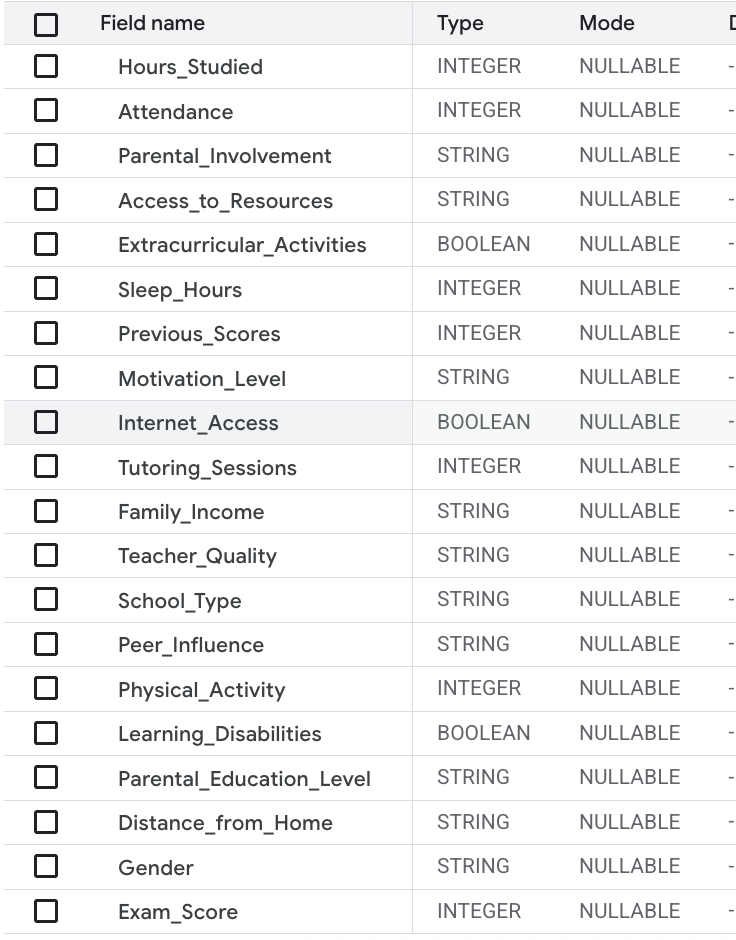  

I'm interested in seeing if most of the columns correlate with a higher score as well as score improvement, in particular the columns regarding attendance, hours spent studying, access to resources, sleep, and tutoring.

## Initial Explorations
I started with exploring the first 10 rows.

<span style="color:blue"> SELECT *   
FROM student_performance   
LIMIT 10</span>        
<br>
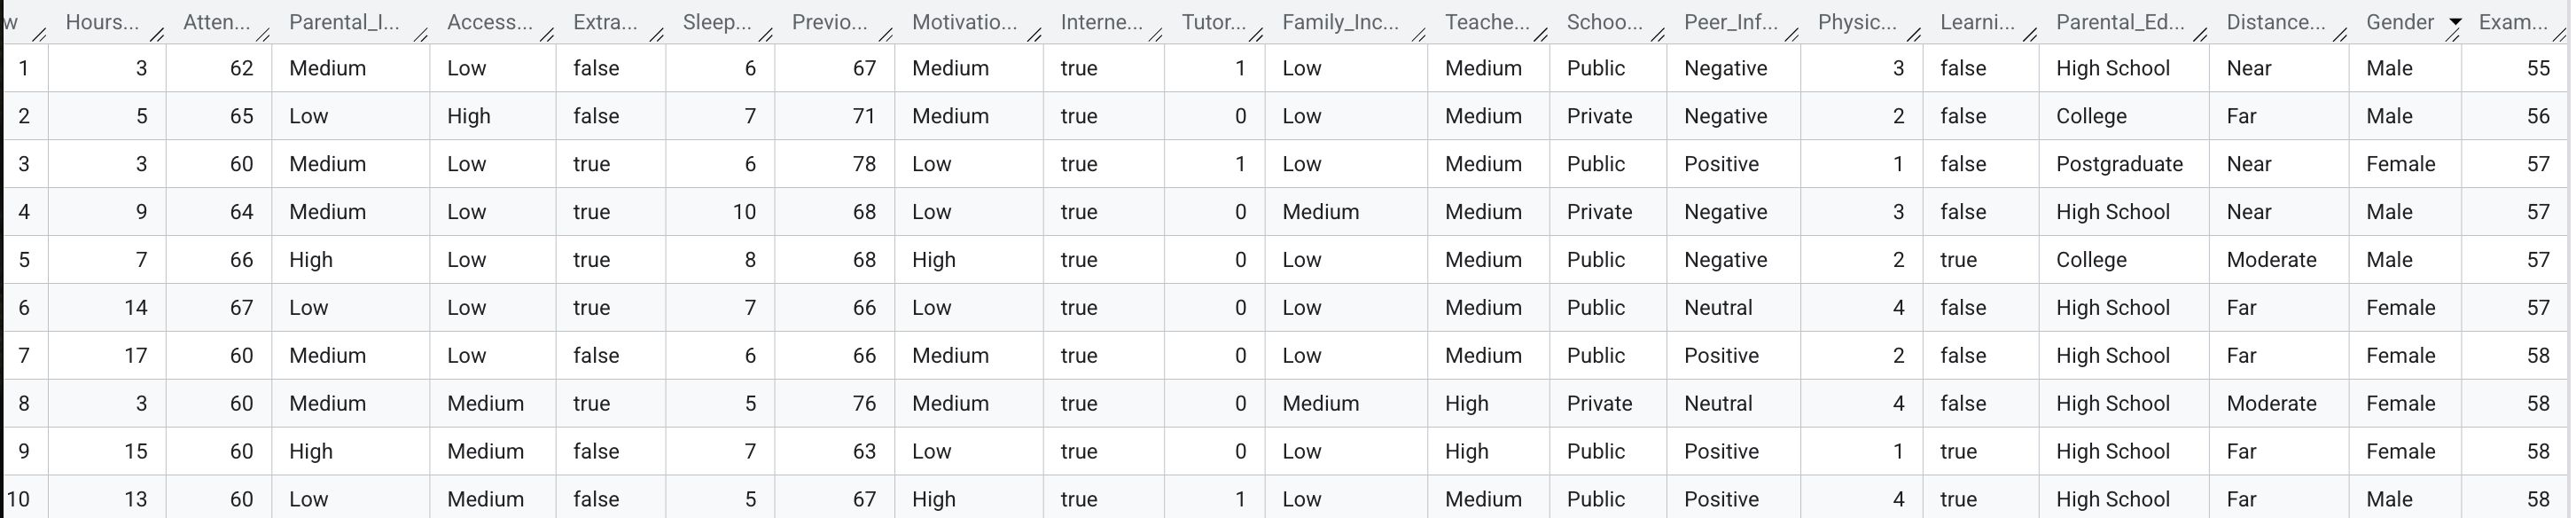  

My initial hypothesis is that attendance, family income, access to resources, and tutoring may be high contributing factors to higher exam scores, but I'm also very interested in how sleep and extra curricular involvement may factor in.
Next I looked for NULLs in the data. I found 3 columns with NULLs, and decided that leaving them as is would not affect my exploration of the data.

<span style="color:blue"> SELECT    
COUNTIF(Teacher_Quality IS NULL) AS Teacher_Quality_Nulls,    
COUNTIF(Parental_Education_Level IS NULL) AS Parental_Ed_Nulls,    
COUNTIF(Distance_From_Home IS NULL) AS Distance_Nulls    
FROM student_performance</span>    
<br>
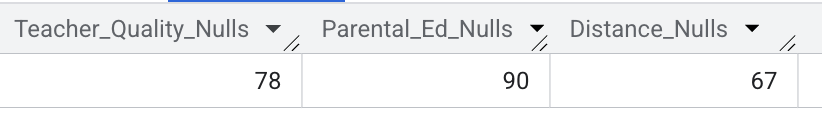  

## Finding Correlations

Digging in, I looked for correlations between each column and the 'Exam_Score' column, as well as with a column I called 'score_diff' that showed the difference between the 'Exam_Score' and 'Previous_Score' columns. To do this, I converted the Boolean and discrete ordinal string columns such as 'Parental_Involvement' to integers, and I used 3 separate queries to keep it tidy(one for numerical, boolean, and ordinal each). Most columns had a correlation between 0 - 0.2, but two columns stood out with much higher correlations: 'Attendance' and 'Hours_Studied'(shown below as 'hours').

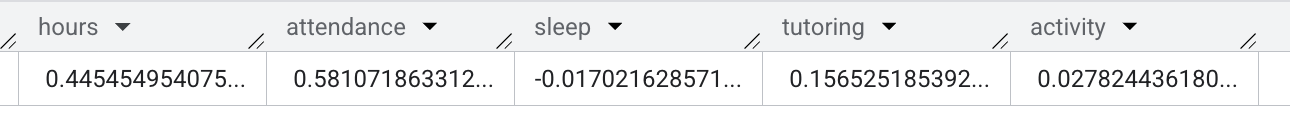  

Next, I assigned a ranking based on 'Exam_Score' and looked at the top 10 students.

<span style="color:blue">SELECT DENSE_RANK () OVER (ORDER BY Exam_Score DESC) AS ranking, *    
FROM student_performance    
LIMIT 10</span>    
<br>
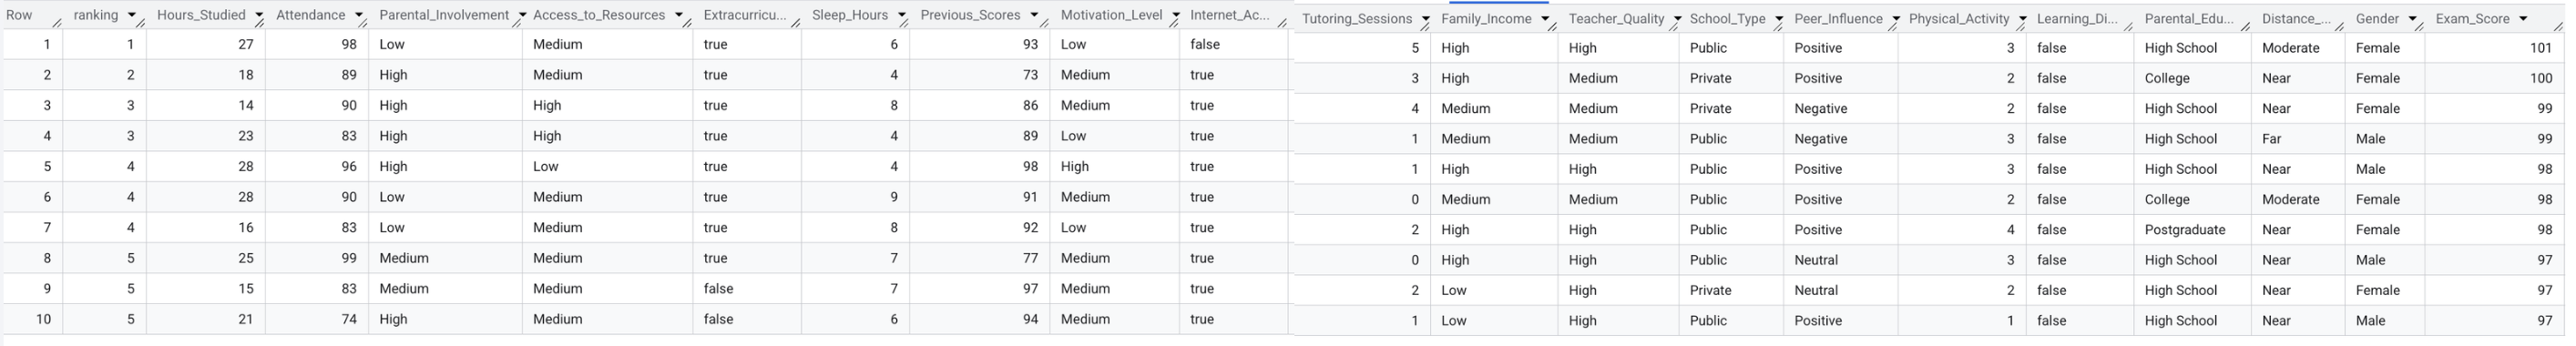 

Just looking at students with the top 10 exam scores confirms that attendance and studying must play a key role in success, but it also raised questions for me about certain other columns such as 'Physical_Activity' and 'Distance_From_Home'.

## Identifying Trends in Grade Buckets

To look at the bigger picture, I started by grouping the students into grade buckets. First I looked at the distribution of grades.

<span style="color:blue"> WITH g AS (    
SELECT    
CASE WHEN Exam_Score >= 90 THEN 'A'     
WHEN Exam_Score BETWEEN 80 AND 89 THEN 'B'    
WHEN Exam_Score BETWEEN 70 AND 79 THEN 'C'    
ELSE 'D-Lower'    
END AS grade,    
COUNT ( * ) AS student_total  
FROM student_performance    
GROUP BY grade    
)    
SELECT *, ROUND((student_total/(SUM(student_total) OVER ()))*100, 2) AS percent_of_total    
FROM g     
GROUP BY grade, student_total    
UNION ALL    
SELECT 'Total Students:' AS grade, COUNT( * ) AS student_total, 1 AS percent_of_total    
FROM student_performance    
ORDER BY grade</span>    
<br>
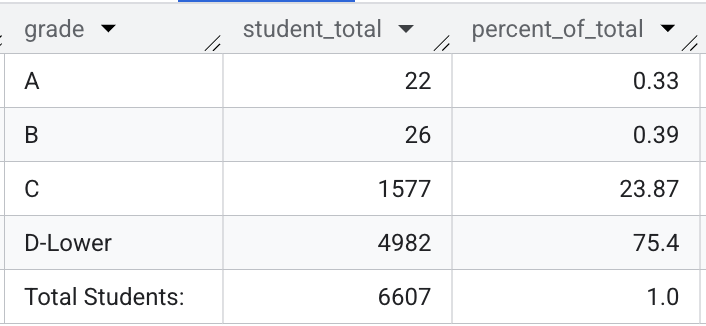  

<br>
This reveals that the data is skewed primarily towards lower grades, with 75% of the data coming from students with grades lower than 70.   
<br>Next I looked at my columns of interest and found the averages within their respective grade buckets, and found unexpected results among the B and C grade students.  

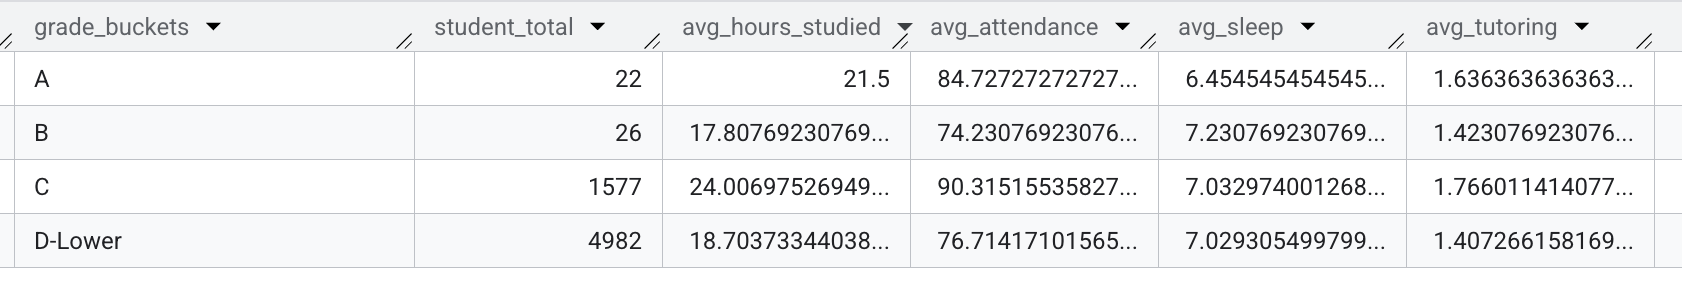  

I broke down attendance by 'Attendance' ranking and also as a crosstab across the grade_buckets.

<span style="color:blue">  SELECT Attendance, AVG(Exam_Score) as avg_score    
FROM student_performance    
GROUP BY Attendance    
ORDER BY Attendance DESC</span>    
<br>
<br>
<br>
<span style="color:blue">WITH CTE AS (  
SELECT * ,  
CASE  
WHEN Attendance >= 90 THEN '90-100'  
WHEN Attendance BETWEEN 80 AND 89 THEN '80-89'   
WHEN Attendance BETWEEN 70 AND 79 THEN '70-79'  
ELSE '60s or less'  
END AS attendance_bucket  
FROM student_performance  
)  
SELECT attendance_bucket,  
SUM(CASE WHEN Exam_Score > 90 THEN 1 ELSE 0 END) AS A_grades,  
SUM(CASE WHEN Exam_Score BETWEEN 80 AND 89 THEN 1 ELSE 0 END) AS B-grades,   
SUM(CASE WHEN Exam_Score BETWEEN 70 AND 79 THEN 1 ELSE 0 END) AS C_grades,  
SUM(CASE WHEN Exam_Score < 70 THEN 1 ELSE 0 END) AS D_grades  
FROM CTE  
GROUP BY attendance_bucket  
ORDER BY attendance_bucket DESC</span>  
<br>
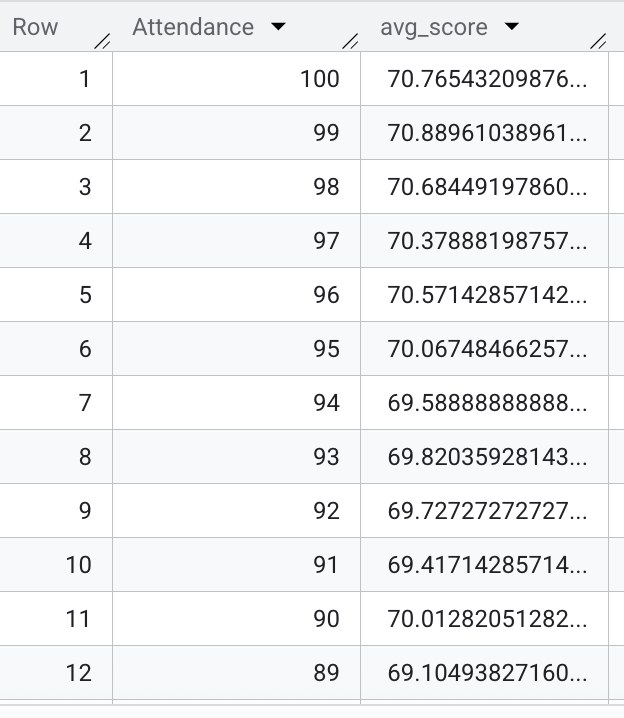  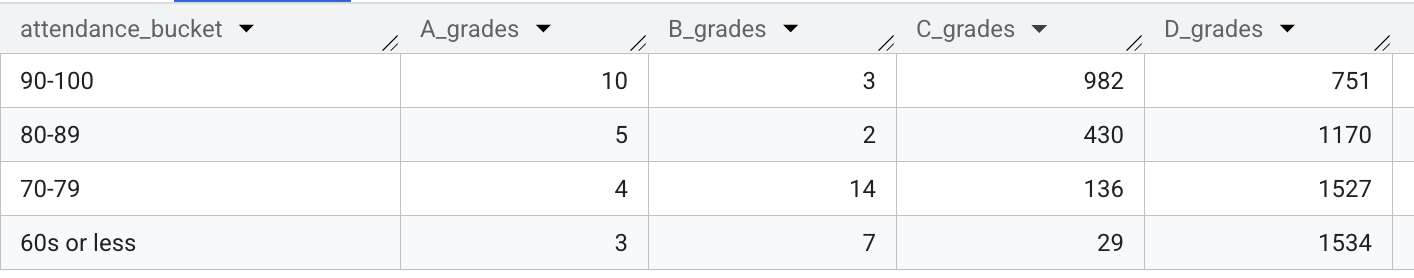      

And then I did the same with 'Hours_Studied'

<span style="color:blue">  SELECT Hours_Studied, ROUND(AVG(Exam_Score), 3) AS avg_exam_score     
FROM student_performance    
GROUP BY Hours_Studied    
ORDER BY Hours_Studied DESC</span>    
<br>
<br>
<br>
<span style="color:blue">WITH CTE AS (  
SELECT *  
CASE  
WHEN Hours_Studied >= 30 THEN '30+'  
WHEN Hours_Studied BETWEEN 25 AND 30 THEN '25-30'  
WHEN Hours_Studied BETWEEN 20 AND 24 THEN '20-25 hours'  
WHEN Hours_Studied BETWEEN 15 AND 19 THEN '15-20 hours'  
WHEN Hours_Studied BETWEEN 10 AND 14 THEN '10-15 hours'  
WHEN Hours_Studied BETWEEN 5 AND 9 THEN '05-10 hours'  
ELSE '0-05 hours'  
END AS study_hours  
FROM student_performance  
)  
SELECT study_hours,  
SUM(CASE WHEN Exam_Score > 90 THEN 1 ELSE 0 END) AS A_grades,  
SUM(CASE WHEN Exam_Score BETWEEN 80 AND 89 THEN 1 ELSE 0 END) AS B_grades,   
SUM(CASE WHEN Exam_Score BETWEEN 70 AND 79 THEN 1 ELSE 0 END) AS C_grades,  
SUM(CASE WHEN Exam_Score < 70 THEN 1 ELSE 0 END) AS D_grades  
FROM CTE  
GROUP BY study_hours  
ORDER BY study_hours DESC</span>  
<br>
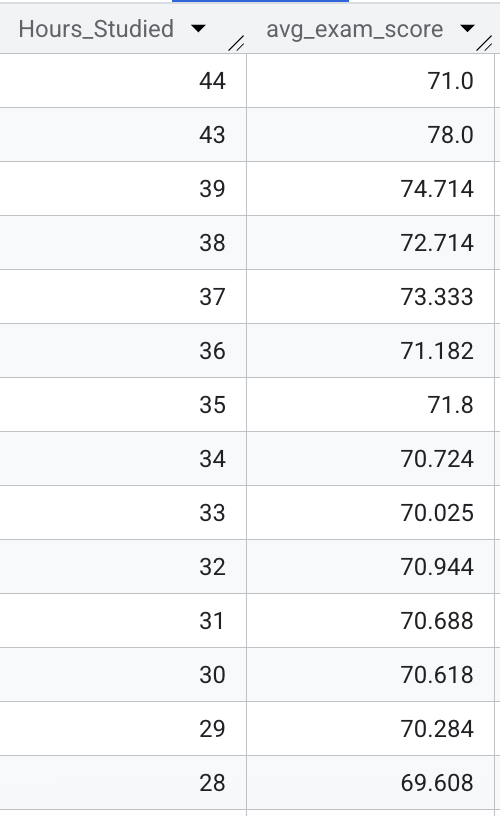 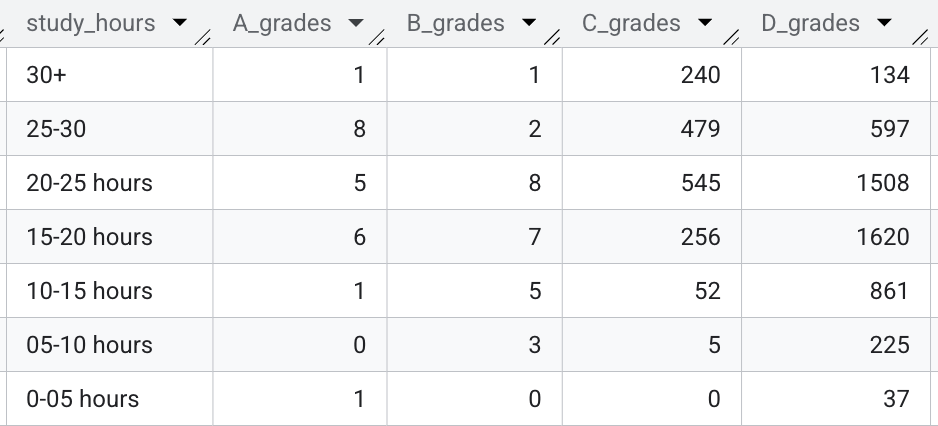

Next, I looked to see if involvement in Extracurriculars impacted scores. Not only did I compare the rankings of those in extracurriculars and those who weren't, but I also compared the rankings and average scores within categories of attendance and hours studied. This showed that there is a clear pattern of students involved in Extra Curriculars having a higher score!

<span style="color:blue"> WITH t AS(      
  SELECT DISTINCT DENSE_RANK() OVER (ORDER BY Exam_Score DESC) AS rank, Exam_Score AS yes_ecs      
  FROM student_performance      
  WHERE Extracurricular_Activities = True      
),      
f AS (      
  SELECT DISTINCT DENSE_RANK() OVER (ORDER BY Exam_Score DESC) AS rank, Exam_Score AS no_ecs      
  FROM student_performance    
  WHERE Extracurricular_Activities = False    
)    
SELECT t.rank, yes_ecs, no_ecs    
FROM t    
JOIN f    
ON t.rank=f.rank    
</span>    
<br>
<br>
<br>
<span style="color:blue">WITH ect AS(  
SELECT Hours_Studied, ROUND(AVG(Exam_Score), 3) AS Yes_extras_avg_exam_score   
FROM student_performance  
WHERE Hours_Studied BETWEEN 15 AND 30 AND Extracurricular_Activities = True  
GROUP BY Hours_Studied  
ORDER BY Hours_Studied DESC  
),  
ecf AS(  
SELECT Hours_Studied, ROUND(AVG(Exam_Score), 3) AS No_extras_avg_exam_score   
FROM student_performance  
WHERE Hours_Studied BETWEEN 15 AND 30 AND Extracurricular_Activities = False  
GROUP BY Hours_Studied  
ORDER BY Hours_Studied DESC  
)  
SELECT ect.Hours_Studied, Yes_extras_avg_exam_score, No_extras_avg_exam_score,  
CASE  
WHEN ect.Yes_extras_avg_exam_score > ecf.No_extras_avg_exam_score THEN 'Yes Extras'  
WHEN ect.Yes_extras_avg_exam_score < ecf.No_extras_avg_exam_score THEN 'No Extras'  
END AS Higher_Score  
FROM ect  
JOIN ecf  
ON ect.Hours_Studied = ecf.Hours_Studied  
ORDER BY ect.Hours_Studied DESC</span>  
  
<br>

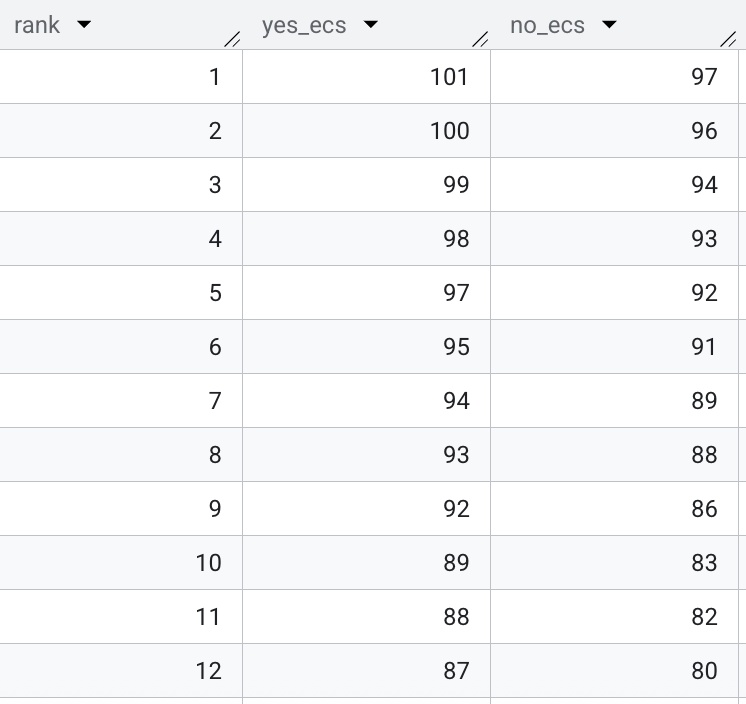  
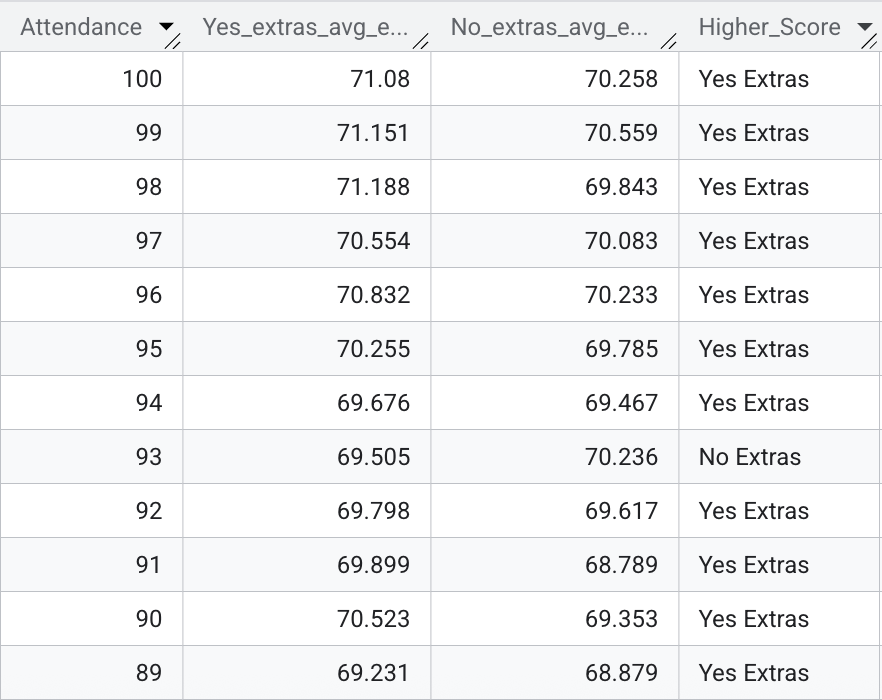 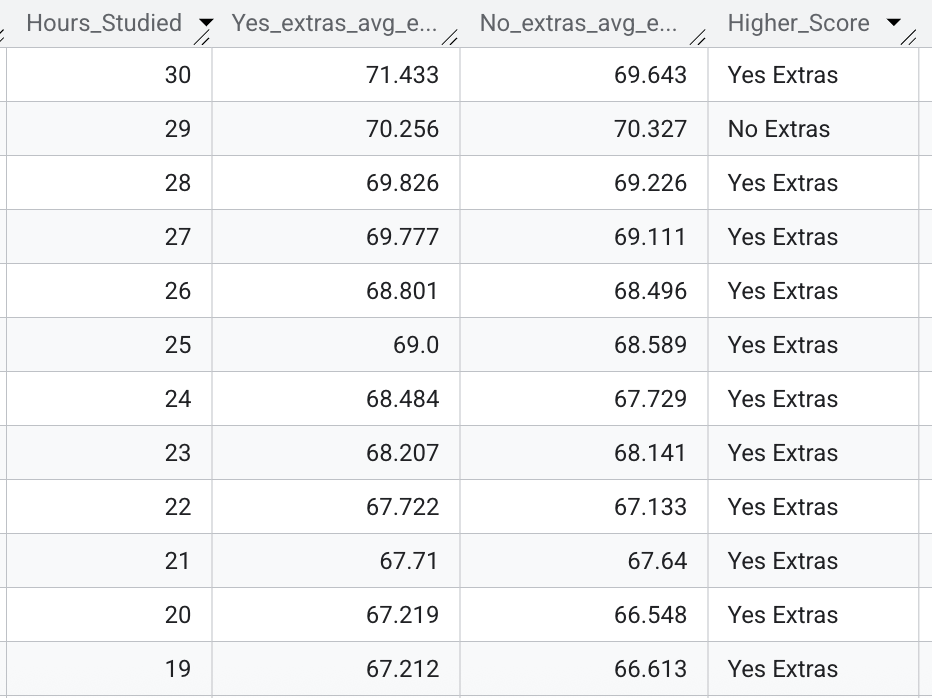  

Finally, I looked at the distribution of sleep, physical activity, distance from home, income, and resources across the grade buckets. 
<br>This revealed:
- There seems to be a sweet spot for Hours of Sleep from 6-7
- There also seems to be a sweet spot in Physical Activity level, from 2-4
- A slightly higher percentage of students who live far away from school score D-lower(83%) compared to 'Moderate'(78%) and 'Near'(73%)
- Family Income was more skewed toward 'Low' to begin with and didn't seem to have any impact on scores
- 85% of students with 'Low' resource access earned D-Lower, compared to 77% of 'Medium' resource access students, and only 65% of 'High' resource access students which shows the resource access does likely partially contribute to higher scores

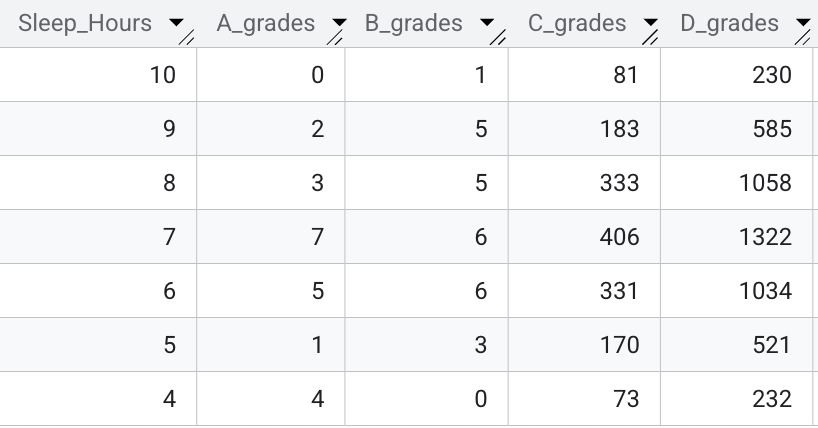 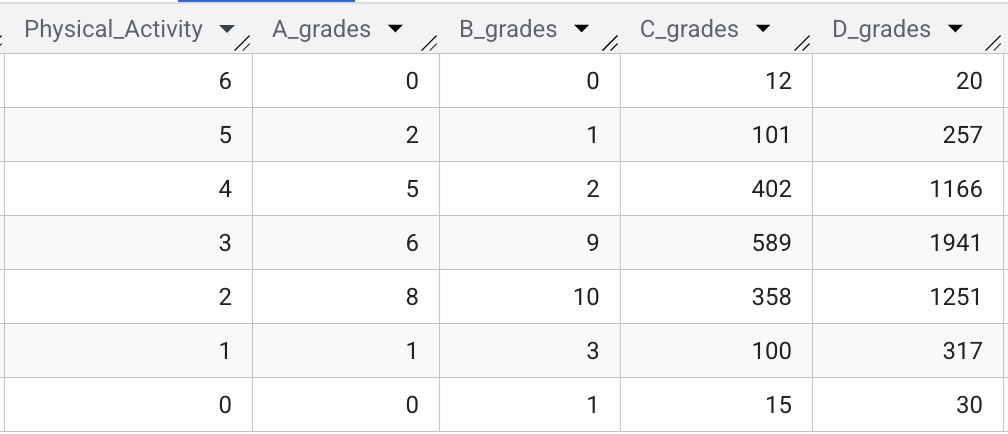
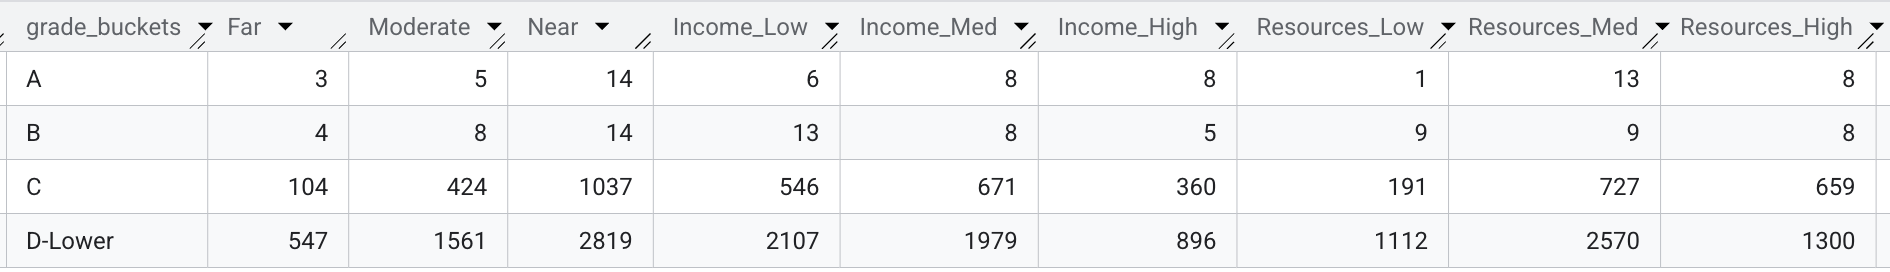  

## Confirming Hypotheses with Improvement Scores

To further provide evidence of what elements seemed to impact scores, I used the previous scores and exam scores to group the students into those who improved and those who had not and compared the numerical categories. 

<span style="color:blue">SELECT  
CASE WHEN (Exam_Score - Previous_Scores) > 0 THEN 'Improved'  
ELSE 'Not Improved'  
END AS improvement_status,  
ROUND (AVG (Attendance), 2) AS avg_attendance,  
ROUND (AVG(Hours_Studied), 2) AS avg_hours_studied,  
ROUND (AVG (Sleep_Hours), 2) AS avg_sleep,  
ROUND (AVG (Physical_Activity), 2) AS avg_activity,  
ROUND (AVG (Tutoring_Sessions), 2) AS avg_tutoring  
FROM student_performance  
GROUP BY improvement_status</span>  


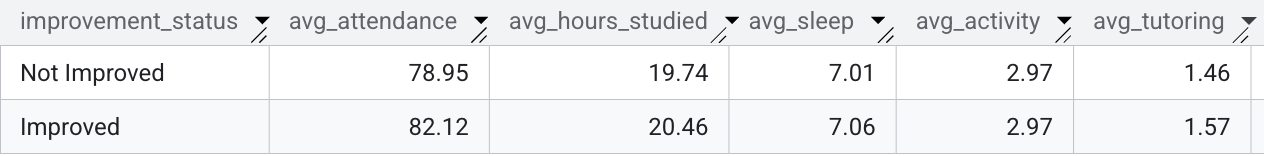  

## Conclusion

While many of these observations cannot be confirmed as causes of higher scores, they can be used to give students and parents a guide for habits of successful students.
I would suggest to students and parents:
- Get 6-7 hours of sleep each night
- Attend at least 90% of classes
- Study between 15-30 hours a week
- Participation in extracurriculars does not take away from high exam scores
- Aim for moderate levels of physical activity

For future studies, I would suggest making the testing process more uniform, and adding a third exam score(one score for beginning, middle, and end of year). I would also suggest adding details like which extracurriculars the student participates in, clarifying the 'Peer_Influence' column(is it regarding life in general or specifically their studies?), if the student takes advanced classes, and stress-level. 

## Thank you!

Thank you so much for checking out my project. I'd love any feedback or questions! I'd also love to connect with you on [LinkedIn](http://www.linkedin.com/in/nicole-t-robbins) 😊